# Análise dos Outputs Consolidados

Notebook para análise dos resultados **já consolidados entre as 5 seeds**

## 0. Setup

In [46]:
import itertools
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# Tamanhos de fonte dos gráficos
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})
FS_ANNOT = 10  # ids de usuário anotados nos pontos/linhas
FS_CD = 12     # rótulos dos diagramas de diferença crítica

# Nomes exibidos nos gráficos (siglas em maiúsculo)
CLF_LABELS = {'knn': 'KNN', 'mlp': 'MLP', 'random-forest': 'Random Forest'}
DATASET_LABELS = {'balabit': 'Balabit', 'bogazici': 'Bogazici', 'minecraft': 'Minecraft'}


def clf_label(clf):
    return CLF_LABELS.get(clf, clf)


def ds_label(dataset):
    return DATASET_LABELS.get(dataset, dataset)


def titulo(clf, dataset):
    """Título no padrão 'KNN (Balabit)'."""
    return f"{clf_label(clf)} ({ds_label(dataset)})"


def rotular_classificadores(ax, ordem):
    """Troca os rótulos do eixo x (nomes crus dos classificadores) pelos nomes de exibição."""
    ax.set_xticks(range(len(ordem)))
    ax.set_xticklabels([clf_label(c) for c in ordem])

CONSOLIDADO_DIR = Path('../consolidado')
CONFIG_CSV = CONSOLIDADO_DIR / 'resumo_por_config.csv'
USER_CSV = CONSOLIDADO_DIR / 'resumo_por_usuario.csv'

# Pasta onde cada gráfico é salvo como PDF individual
PDF_DIR = Path('graficos_pdf')
PDF_DIR.mkdir(exist_ok=True)


def save_pdf(fig, name):
    """Salva a figura como um PDF individual em PDF_DIR/{name}.pdf"""
    path = PDF_DIR / f'{name}.pdf'
    fig.savefig(path, bbox_inches='tight')
    print(f'salvo: {path}')


## 1. Carregamento dos dados consolidados

In [47]:
df_config = pd.read_csv(CONFIG_CSV)
df_user = pd.read_csv(USER_CSV)

classifiers = sorted(df_config['classifier'].unique())
datasets = sorted(df_config['dataset'].unique())

print(f"Configs (dataset x classificador x window_size): {len(df_config)}")
print(f"Linhas por usuário (dataset x classificador x window_size x user_id): {len(df_user)}")
print(f"Classificadores : {classifiers}")
print(f"Datasets        : {datasets}")
print(f"Window sizes    : {sorted(df_config['window_size'].unique())}")
df_config.head()


Configs (dataset x classificador x window_size): 48
Linhas por usuário (dataset x classificador x window_size x user_id): 1128
Classificadores : ['knn', 'mlp', 'random-forest']
Datasets        : ['balabit', 'bogazici', 'minecraft']
Window sizes    : [np.int64(10), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250)]


,dataset,classifier,window_size,n_seeds,seeds_usadas,n_users_mean,n_users_consistente,n_users_skipped_mean,mean_score_n,mean_score_mean,...,mean_precision_macro_max,mean_precision_macro_median,mean_precision_macro_cv,mean_recall_macro_n,mean_recall_macro_mean,mean_recall_macro_std,mean_recall_macro_min,mean_recall_macro_max,mean_recall_macro_median,mean_recall_macro_cv
0,balabit,knn,10,5,"001,002,003,004,005",10.0,True,0.0,5,0.654809,...,0.651175,0.650412,0.001604,5,0.667106,0.000940,0.665718,0.667897,0.667637,0.001410
1,balabit,knn,100,5,"001,002,003,004,005",10.0,True,0.0,5,0.676568,...,0.680871,0.675672,0.006385,5,0.689223,0.004099,0.684189,0.693747,0.690820,0.005947
2,balabit,knn,150,5,"001,002,003,004,005",10.0,True,0.0,5,0.684936,...,0.695536,0.684156,0.008994,5,0.694382,0.005974,0.687176,0.703698,0.694246,0.008603
3,balabit,knn,200,5,"001,002,003,004,005",10.0,True,0.0,5,0.681753,...,0.689316,0.684261,0.007200,5,0.691694,0.002986,0.688367,0.694994,0.691394,0.004317
4,balabit,knn,250,5,"001,002,003,004,005",10.0,True,0.0,5,0.690893,...,0.697460,0.694391,0.007694,5,0.698973,0.005713,0.691887,0.704922,0.699901,0.008173


## 2. Melhor configuração por classificador / dataset / window_size

Usa `mean_balanced_score_mean`, já agregado sobre as 5 seeds. Não há mais seleção de "melhor run" (seed) — a comparação é entre configurações (`classificador x window_size`), cada uma já resumida por sua média.

In [48]:
print("Melhor configuração por classificador:")
best_by_clf = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby('classifier')
    .first()
    .reset_index()
)
display(best_by_clf[['classifier', 'dataset', 'window_size',
                      'mean_balanced_score_mean', 'mean_balanced_score_std', 'n_seeds']])


Melhor configuração por classificador:


,classifier,dataset,window_size,mean_balanced_score_mean,mean_balanced_score_std,n_seeds
0,knn,minecraft,250,0.704200,0.007446,5
1,mlp,bogazici,100,0.709230,0.002562,5
2,random-forest,balabit,250,0.747576,0.004478,5


In [49]:
print("Melhor configuração por dataset:")
best_by_dataset = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby('dataset')
    .first()
    .reset_index()
)
display(best_by_dataset[['dataset', 'classifier', 'window_size',
                          'mean_balanced_score_mean', 'mean_balanced_score_std', 'n_seeds']])


Melhor configuração por dataset:


,dataset,classifier,window_size,mean_balanced_score_mean,mean_balanced_score_std,n_seeds
0,balabit,random-forest,250,0.747576,0.004478,5
1,bogazici,random-forest,250,0.715573,0.002642,5
2,minecraft,knn,250,0.704200,0.007446,5


In [50]:
print("Melhor configuração por window_size:")
best_by_window = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby('window_size')
    .first()
    .reset_index()
)
display(best_by_window[['window_size', 'dataset', 'classifier',
                         'mean_balanced_score_mean', 'mean_balanced_score_std', 'n_seeds']])


Melhor configuração por window_size:


,window_size,dataset,classifier,mean_balanced_score_mean,mean_balanced_score_std,n_seeds
0,10,balabit,random-forest,0.720421,0.001197,5
1,50,balabit,random-forest,0.735786,0.002169,5
2,100,balabit,random-forest,0.741889,0.002856,5
3,150,balabit,random-forest,0.744499,0.003120,5
4,200,balabit,random-forest,0.742663,0.002380,5
5,250,balabit,random-forest,0.747576,0.004478,5


## 3. Melhor window_size por (classificador, dataset)

Usado como base para os gráficos de comparação entre classificadores nas seções 4 e 5.

In [51]:
best_window_per_clf_ds = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby(['classifier', 'dataset'])
    .first()
    .reset_index()
)
display(best_window_per_clf_ds[['classifier', 'dataset', 'window_size',
                                 'mean_balanced_score_mean', 'mean_balanced_score_std']])

best_window_lookup = (
    best_window_per_clf_ds.set_index(['classifier', 'dataset'])['window_size'].to_dict()
)


,classifier,dataset,window_size,mean_balanced_score_mean,mean_balanced_score_std
0,knn,balabit,250,0.698973,0.005713
1,knn,bogazici,250,0.661685,0.001071
2,knn,minecraft,250,0.704200,0.007446
3,mlp,balabit,200,0.707746,0.007651
4,mlp,bogazici,100,0.709230,0.002562
5,mlp,minecraft,200,0.617457,0.011535
6,random-forest,balabit,250,0.747576,0.004478
7,random-forest,bogazici,250,0.715573,0.002642
8,random-forest,minecraft,150,0.632331,0.008614


---
## 4. Scatter de usuários: classificador X vs classificador Y

Cada ponto é um usuário; os eixos são o `balanced_score_mean` (já média sobre as 5 seeds) na melhor `window_size` de cada classificador. **Uma figura PDF separada por (dataset, par de classificadores).**

salvo: graficos_pdf\scatter_balabit_knn-vs-mlp.pdf


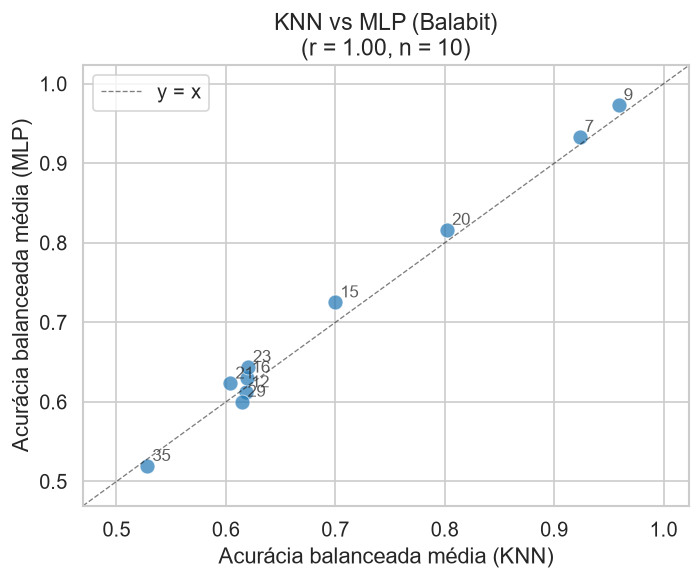

salvo: graficos_pdf\scatter_balabit_knn-vs-random-forest.pdf


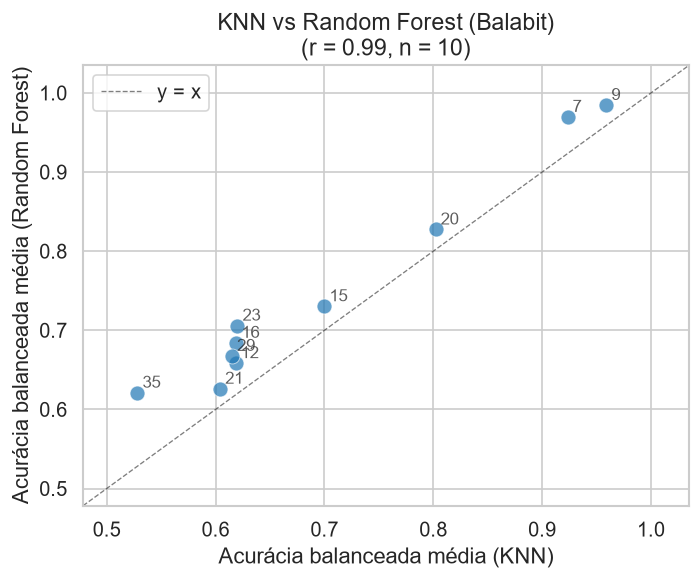

salvo: graficos_pdf\scatter_balabit_mlp-vs-random-forest.pdf


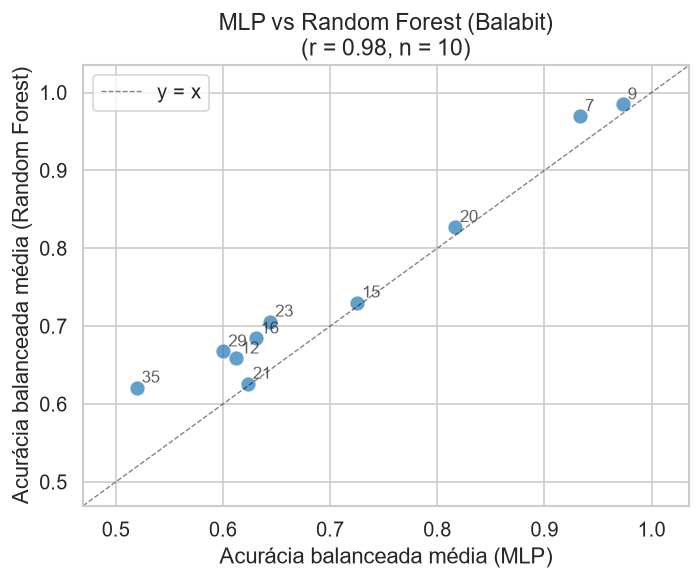

salvo: graficos_pdf\scatter_bogazici_knn-vs-mlp.pdf


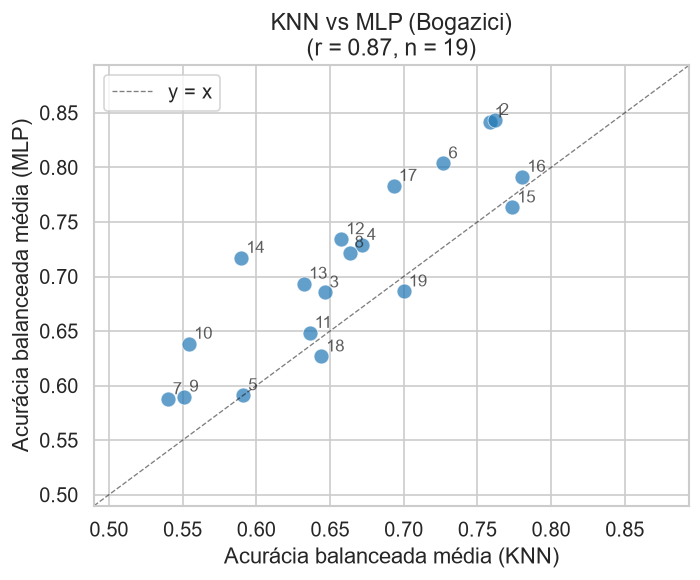

salvo: graficos_pdf\scatter_bogazici_knn-vs-random-forest.pdf


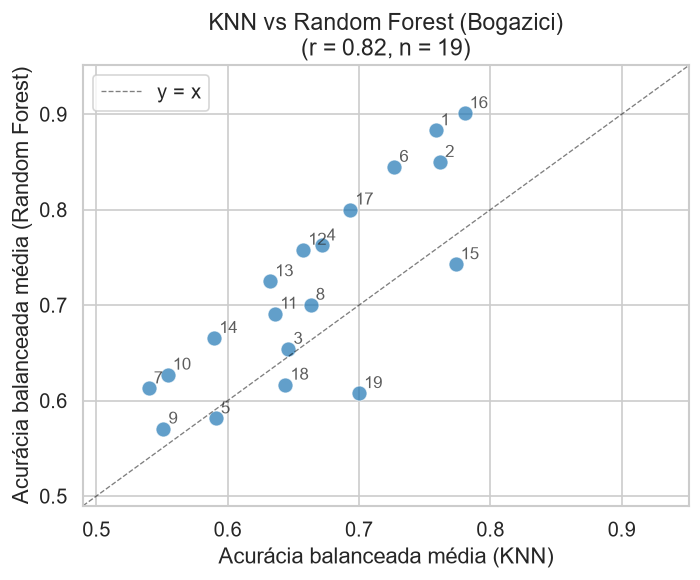

salvo: graficos_pdf\scatter_bogazici_mlp-vs-random-forest.pdf


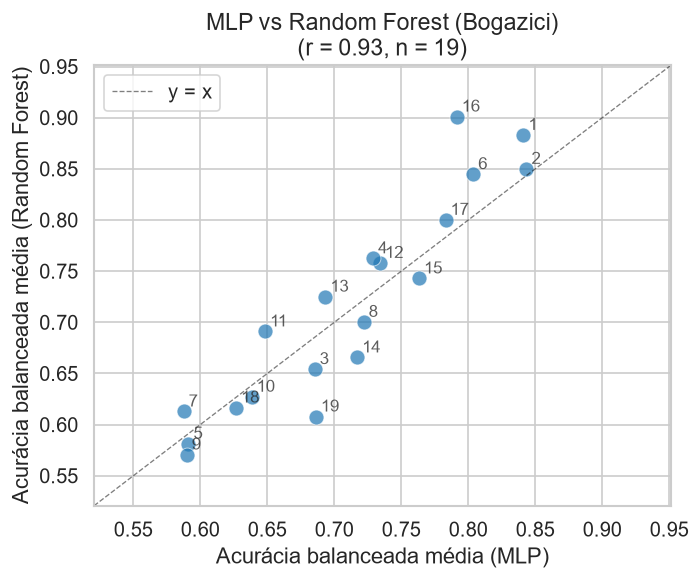

salvo: graficos_pdf\scatter_minecraft_knn-vs-mlp.pdf


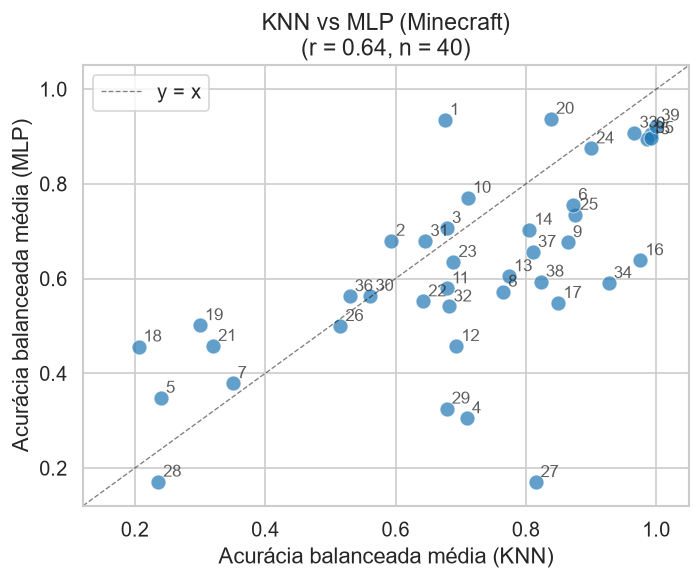

salvo: graficos_pdf\scatter_minecraft_knn-vs-random-forest.pdf


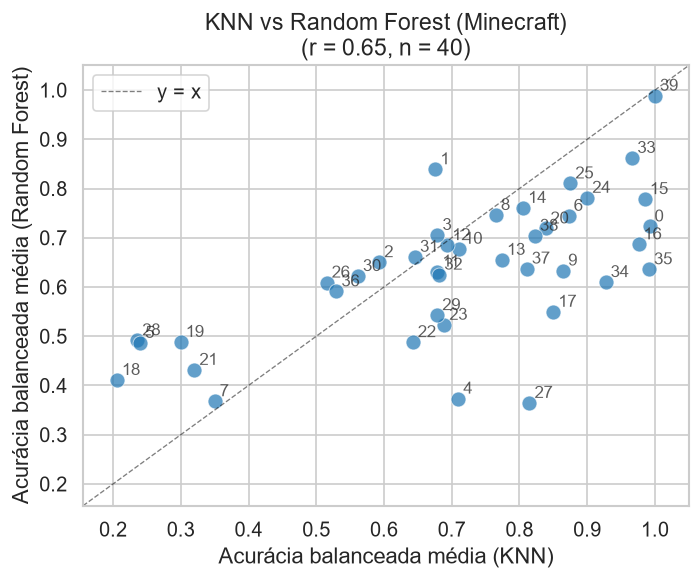

salvo: graficos_pdf\scatter_minecraft_mlp-vs-random-forest.pdf


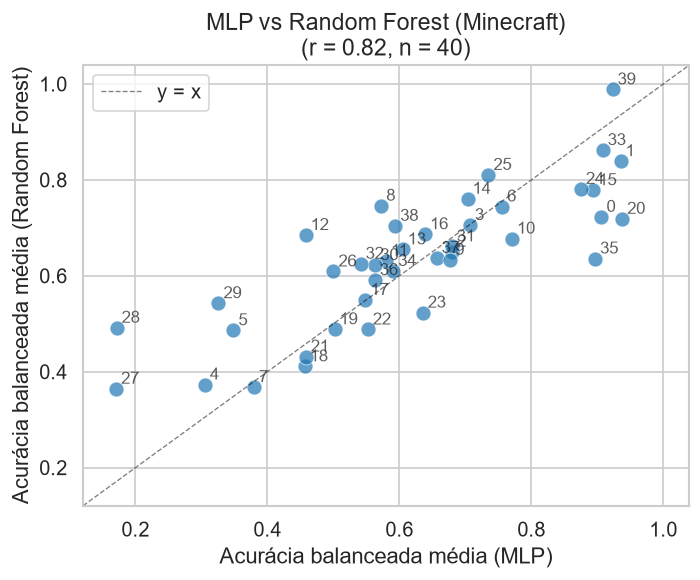

In [52]:
def get_user_scores(classifier, dataset):
    """Retorna Series user_id -> balanced_score_mean na melhor window_size."""
    win = best_window_lookup.get((classifier, dataset))
    if win is None:
        return None
    sub = df_user[
        (df_user['classifier'] == classifier) &
        (df_user['dataset'] == dataset) &
        (df_user['window_size'] == win)
    ]
    return sub.set_index('user_id')['balanced_score_mean']


pairs = list(itertools.combinations(classifiers, 2))

for dataset in datasets:
    for clf_x, clf_y in pairs:
        scores_x = get_user_scores(clf_x, dataset)
        scores_y = get_user_scores(clf_y, dataset)

        if scores_x is None or scores_y is None:
            continue

        common_users = scores_x.index.intersection(scores_y.index)
        if len(common_users) == 0:
            continue

        x = scores_x.loc[common_users].values
        y = scores_y.loc[common_users].values

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(x, y, alpha=0.7, edgecolors='white', linewidth=0.5, s=80)

        lim = (min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05)
        ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5, label='y = x')
        ax.set_xlim(lim)
        ax.set_ylim(lim)

        for uid, xi, yi in zip(common_users, x, y):
            ax.annotate(uid, (xi, yi), fontsize=FS_ANNOT, ha='left',
                        xytext=(3, 3), textcoords='offset points', alpha=0.75)

        corr = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{clf_label(clf_x)} vs {clf_label(clf_y)} ({ds_label(dataset)})\n"
                     f"(r = {corr:.2f}, n = {len(common_users)})")
        ax.set_xlabel(f"Acurácia balanceada média ({clf_label(clf_x)})")
        ax.set_ylabel(f"Acurácia balanceada média ({clf_label(clf_y)})")
        ax.legend()
        fig.tight_layout()

        save_pdf(fig, f"scatter_{dataset}_{clf_x}-vs-{clf_y}")
        plt.show()
        plt.close(fig)


### 5 Boxplot de balanced_score por window_size (por classificador e dataset)

Usa **todas** as `window_size` disponíveis (todas as configs já consolidadas), mostrando a distribuição de `balanced_score_mean` entre usuários em função do tamanho da janela. **Uma figura PDF por (classificador, dataset).**

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_knn_balabit.pdf


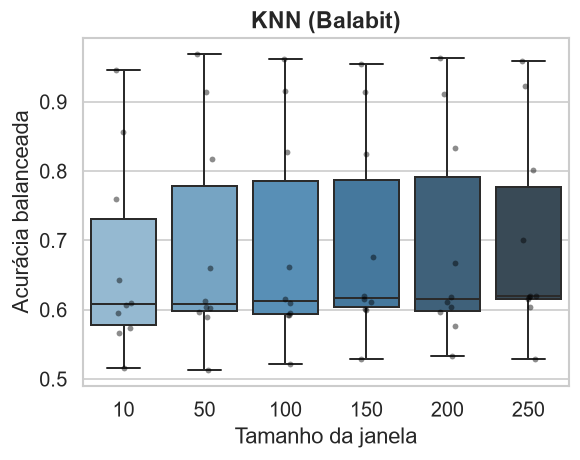

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_knn_bogazici.pdf


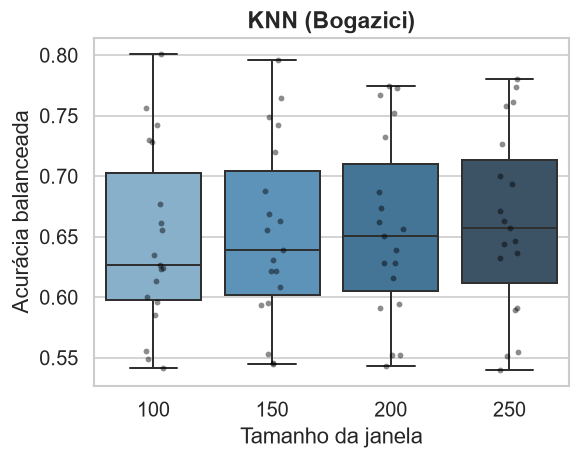

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_knn_minecraft.pdf


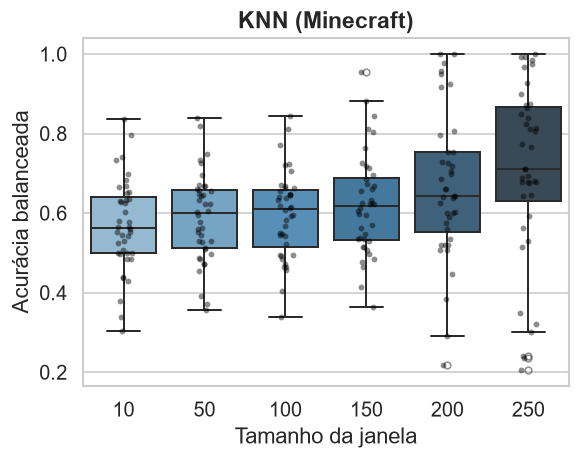

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_mlp_balabit.pdf


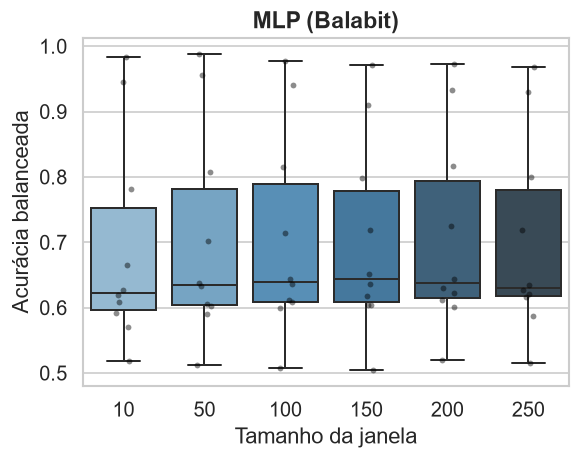

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_mlp_bogazici.pdf


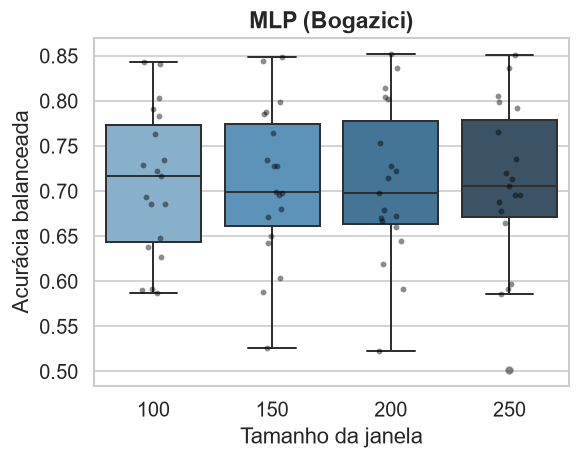

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_mlp_minecraft.pdf


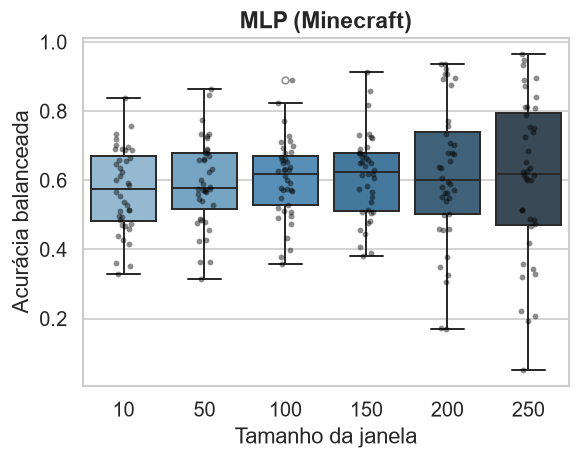

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_random-forest_balabit.pdf


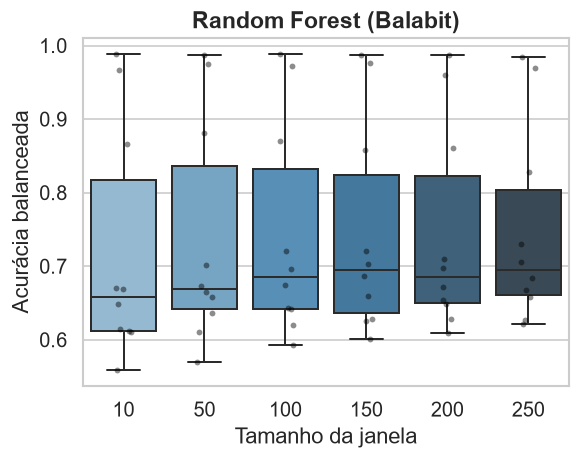

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_random-forest_bogazici.pdf


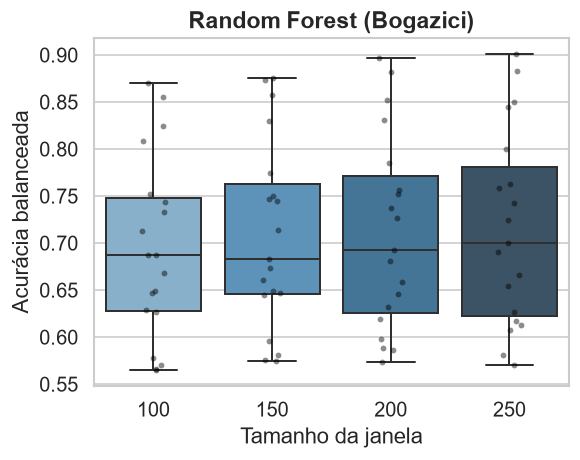

C:\Users\matmo\AppData\Local\Temp\ipykernel_6244\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_random-forest_minecraft.pdf


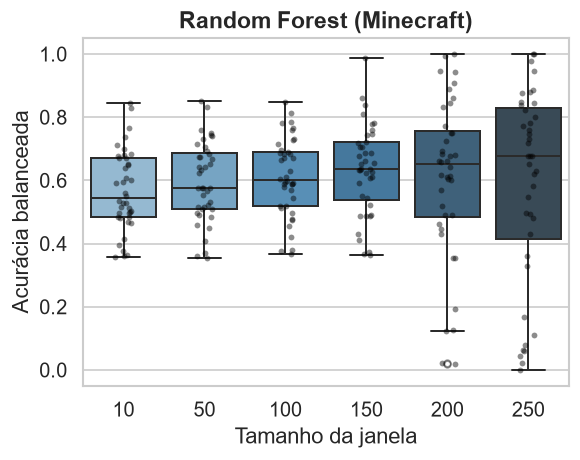

In [53]:
for clf in classifiers:
    for dataset in datasets:
        sub = df_user[(df_user['classifier'] == clf) & (df_user['dataset'] == dataset)]
        if sub.empty:
            continue

        ws_present = sorted(sub['window_size'].unique())

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.boxplot(
            data=sub, x='window_size', y='balanced_score_mean', order=ws_present,
            palette='Blues_d', linewidth=1.2,
            flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax,
        )
        sns.stripplot(
            data=sub, x='window_size', y='balanced_score_mean', order=ws_present,
            color='black', alpha=0.45, size=3.5, jitter=True, ax=ax,
        )
        ax.set_title(titulo(clf, dataset), fontweight='bold')
        ax.set_xlabel("Tamanho da janela")
        ax.set_ylabel("Acurácia balanceada")
        ax.tick_params(axis='x', rotation=0)
        fig.tight_layout()

        save_pdf(fig, f"boxplot_window_{clf}_{dataset}")
        plt.show()
        plt.close(fig)


---
## 6. Heatmap: balanced accuracy por usuário x window_size

**Uma figura PDF por (dataset, classificador).**

salvo: graficos_pdf\heatmap_balabit_knn.pdf


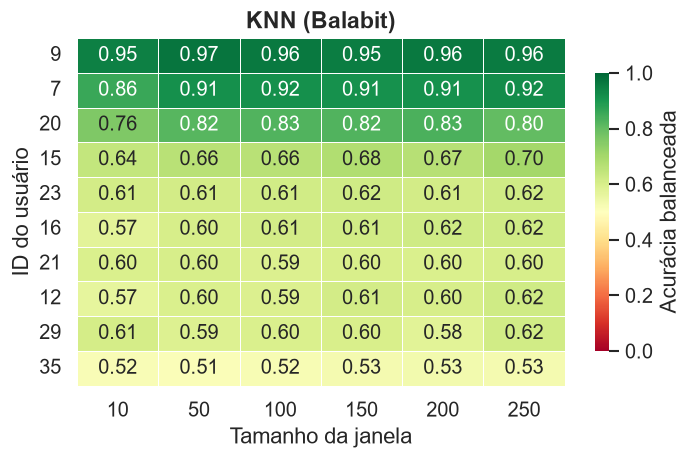

salvo: graficos_pdf\heatmap_balabit_mlp.pdf


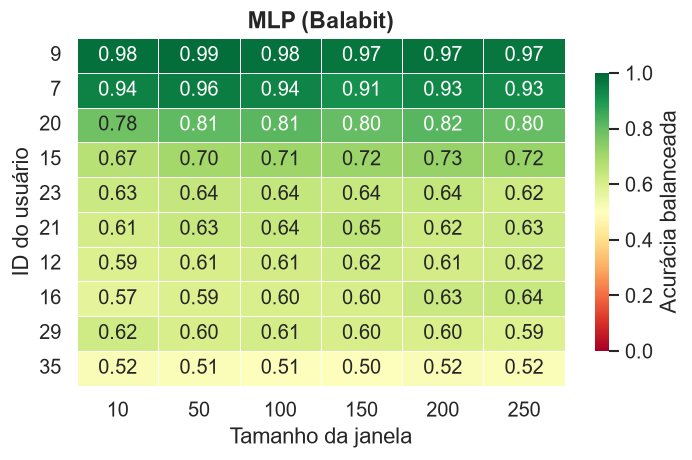

salvo: graficos_pdf\heatmap_balabit_random-forest.pdf


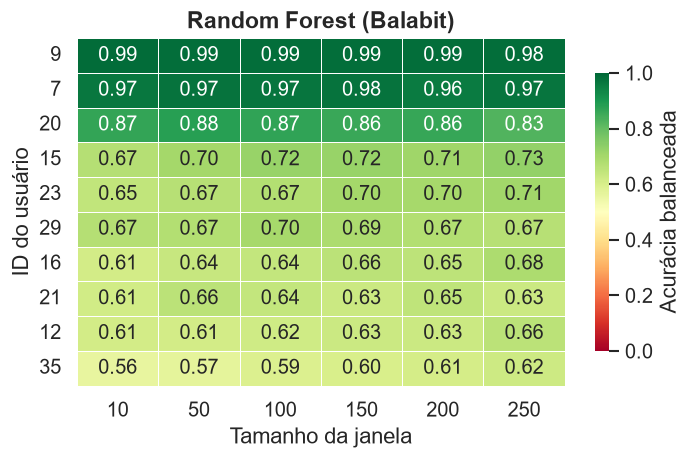

salvo: graficos_pdf\heatmap_bogazici_knn.pdf


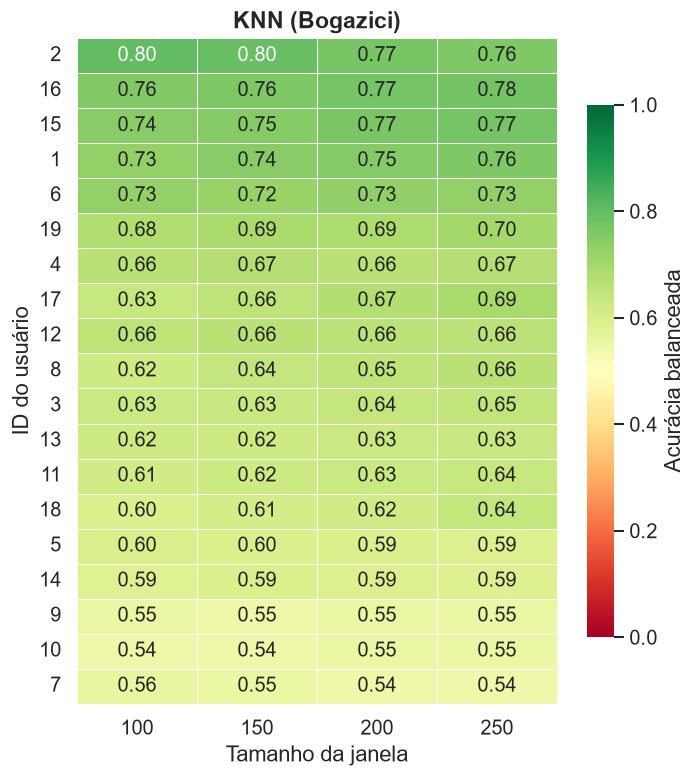

salvo: graficos_pdf\heatmap_bogazici_mlp.pdf


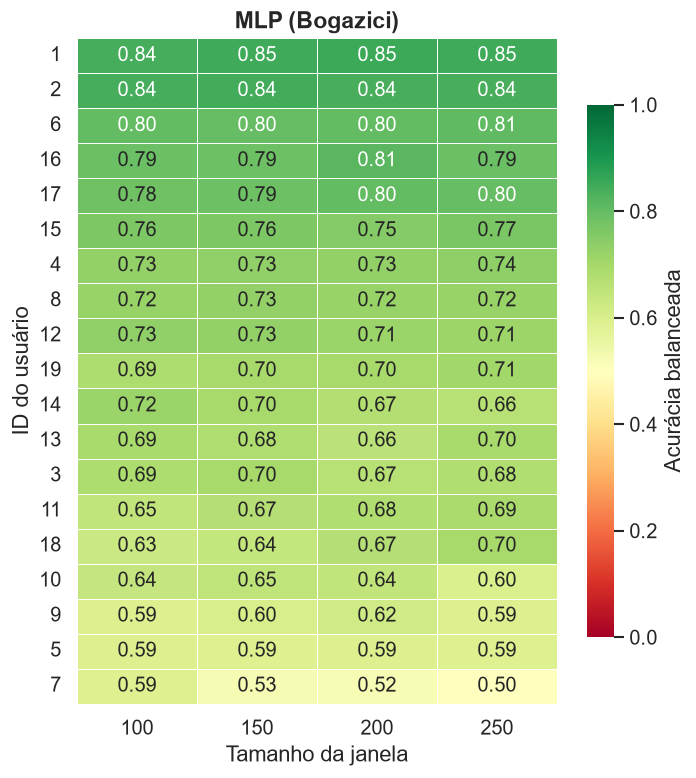

salvo: graficos_pdf\heatmap_bogazici_random-forest.pdf


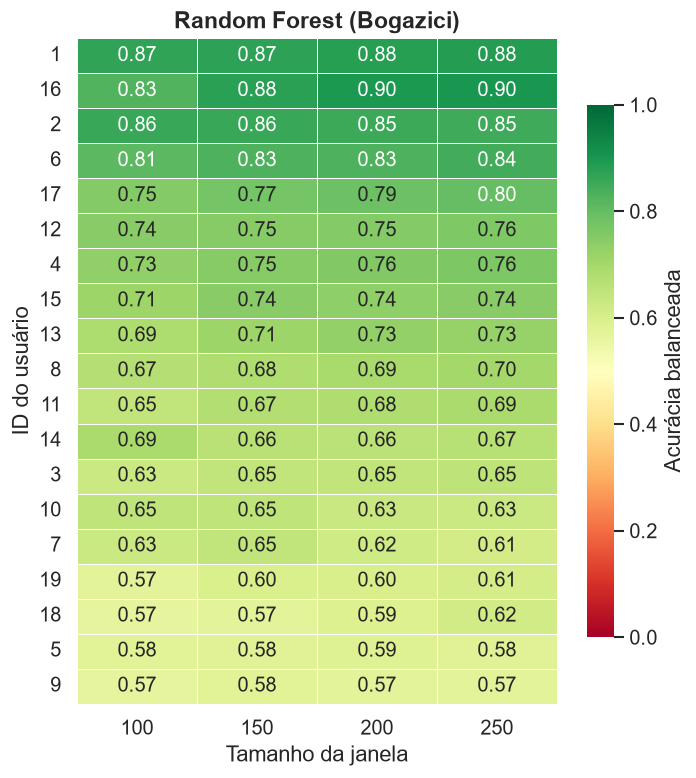

salvo: graficos_pdf\heatmap_minecraft_knn.pdf


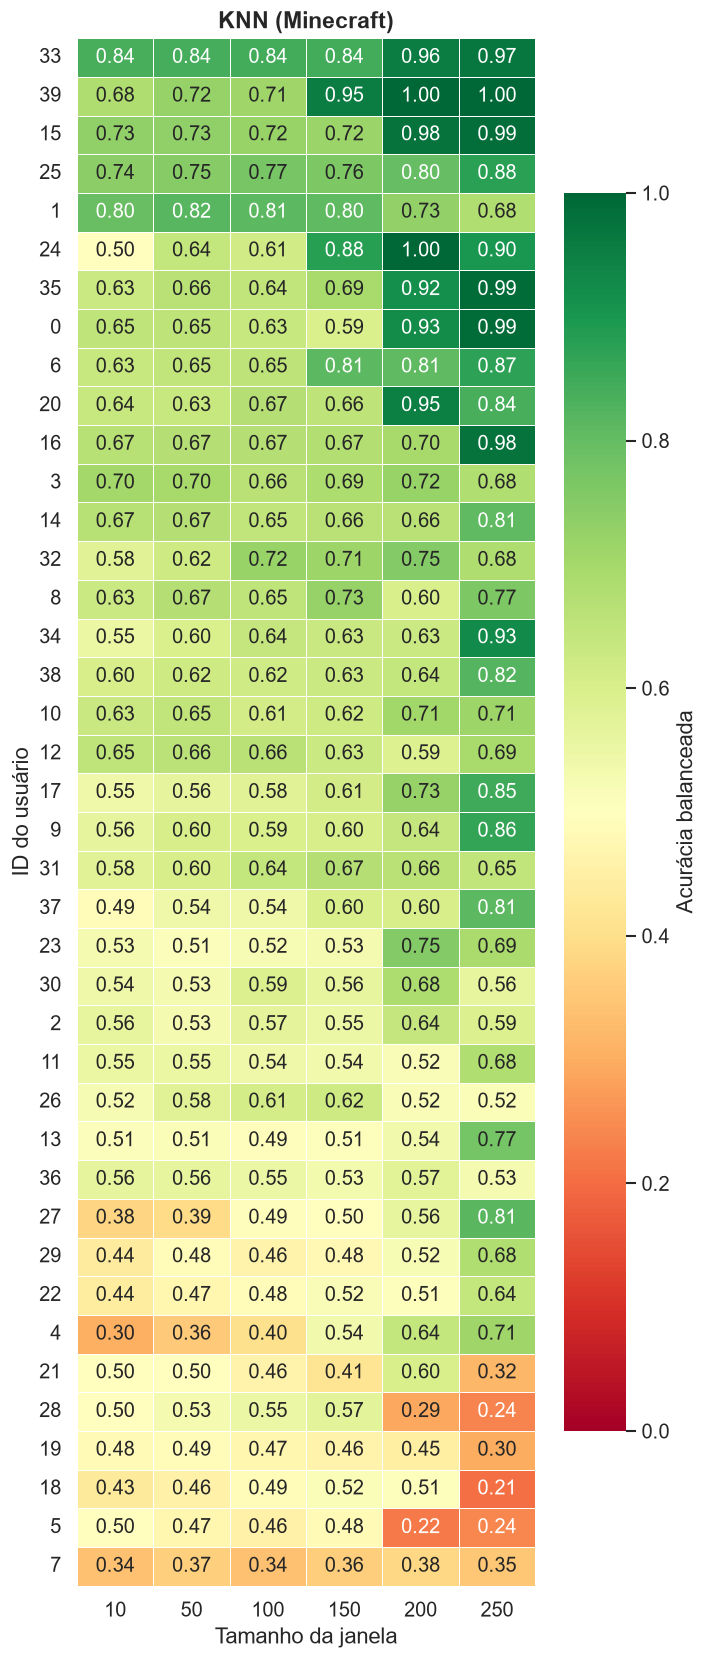

salvo: graficos_pdf\heatmap_minecraft_mlp.pdf


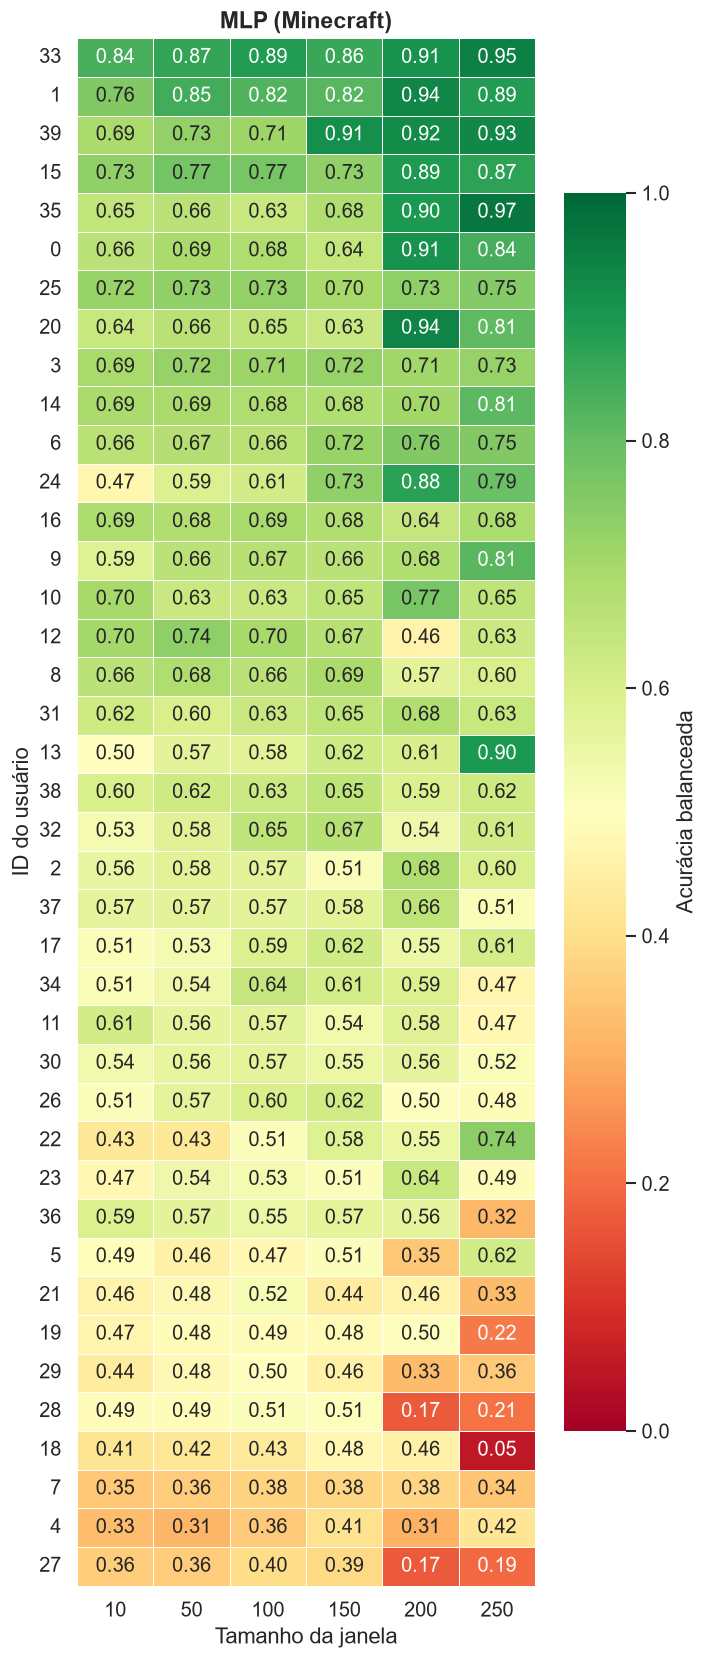

salvo: graficos_pdf\heatmap_minecraft_random-forest.pdf


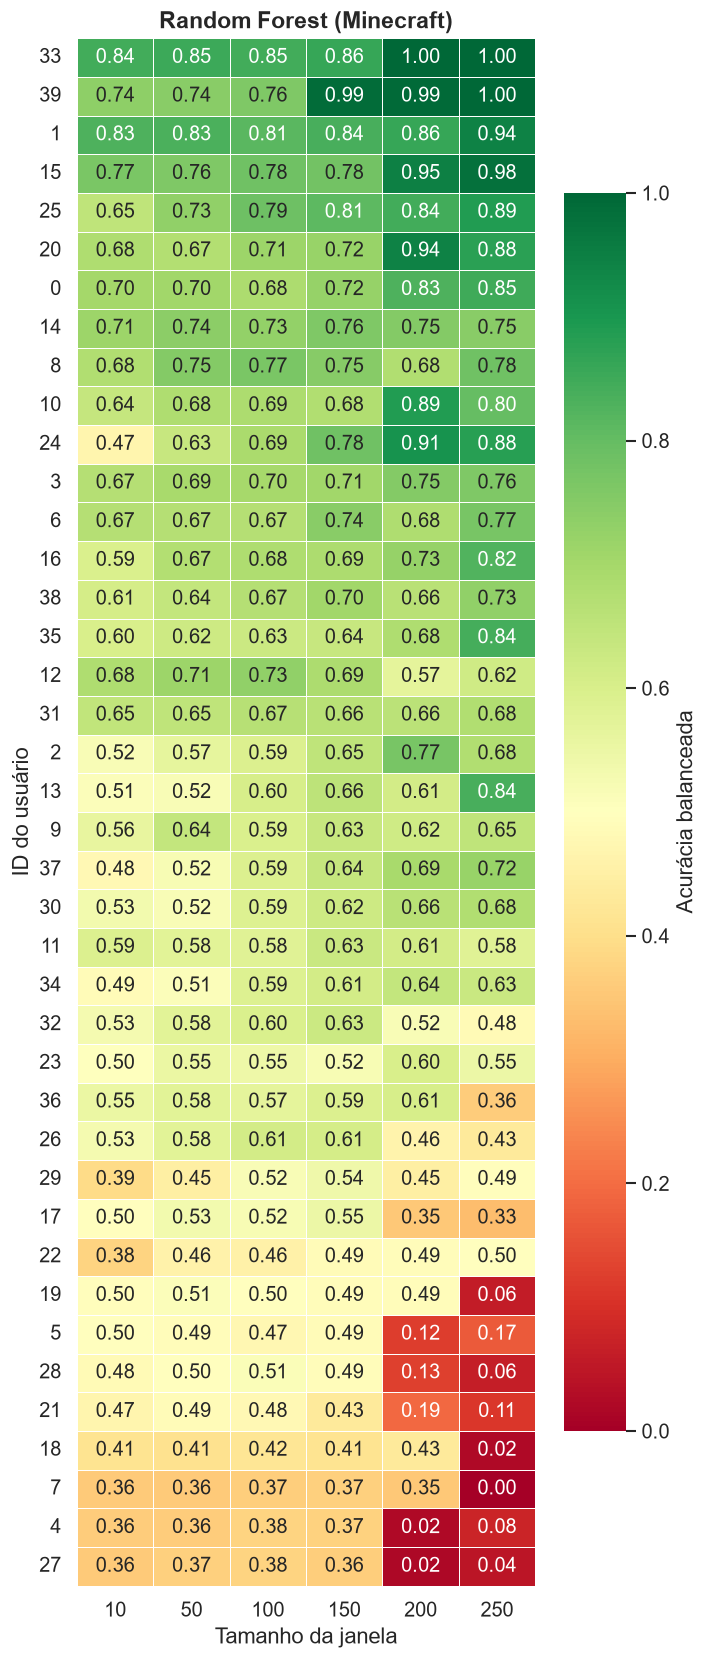

In [ ]:
for dataset in datasets:
    for clf in classifiers:
        sub = df_user[(df_user['dataset'] == dataset) & (df_user['classifier'] == clf)]
        if sub.empty:
            continue

        pivot = (
            sub.pivot_table(index='user_id', columns='window_size', values='balanced_score_mean')
            .sort_index()
        )
        pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

        fig, ax = plt.subplots(figsize=(6, max(4, 0.35 * len(pivot))))
        sns.heatmap(
            pivot, ax=ax, cmap='RdYlGn', vmin=0.0, vmax=1.0,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Acurácia balanceada'},
        )
        ax.set_title(titulo(clf, dataset), fontweight='bold')
        ax.set_xlabel("Tamanho da janela")
        ax.set_ylabel("ID do usuário")
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)
        fig.tight_layout()

        save_pdf(fig, f"heatmap_{dataset}_{clf}")
        plt.show()
        plt.close(fig)
